In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('smartcart_customers.csv')

In [3]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1.Handle Missing Values

In [4]:
df['Income']=df['Income'].fillna(df['Income'].median())

# Feature Engineering

In [5]:
# Age
df['Age']=2026-df['Year_Birth']

In [6]:
#customer joining date
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)
reference_date=df['Dt_Customer'].max()
df['Customer_Tenure_Days']=(reference_date-df['Dt_Customer']).dt.days

In [7]:
#Spending
df['Total_Spending']=df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']

In [8]:
#Children
df['Total_Children']=df['Kidhome'] + df['Teenhome']

In [9]:
df['Education'].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [10]:
#Education
df['Education']= df['Education'].replace({
    'Basic':'Undergraduate','2n Cycle':'Undergraduate',
    'Graduation':'Graduate',
    'Master':'Postgraduate','PhD':'Postgraduate'
})

In [11]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [12]:
df['Living_With']= df['Marital_Status'].replace({
    'Married':'Partner','Together':'Partner',
    'Single':'Alone','Divorced':'Alone','Widow':'Alone','Absurd':'Alone','YOLO':'Alone'
    
})

# Drop Columns

In [13]:
cols=['ID','Marital_Status','Kidhome','Teenhome','Dt_Customer']
spending_columns=['MntWines','MntFruits','MntMeatProducts','MntFishProducts', 'MntSweetProducts','MntGoldProds']

cols_to_drop=cols+spending_columns
df_cleaned=df.drop(columns=cols_to_drop)

In [14]:
df_cleaned.head()

,Year_Birth,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,1957,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,1954,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,1965,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,1984,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,1981,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

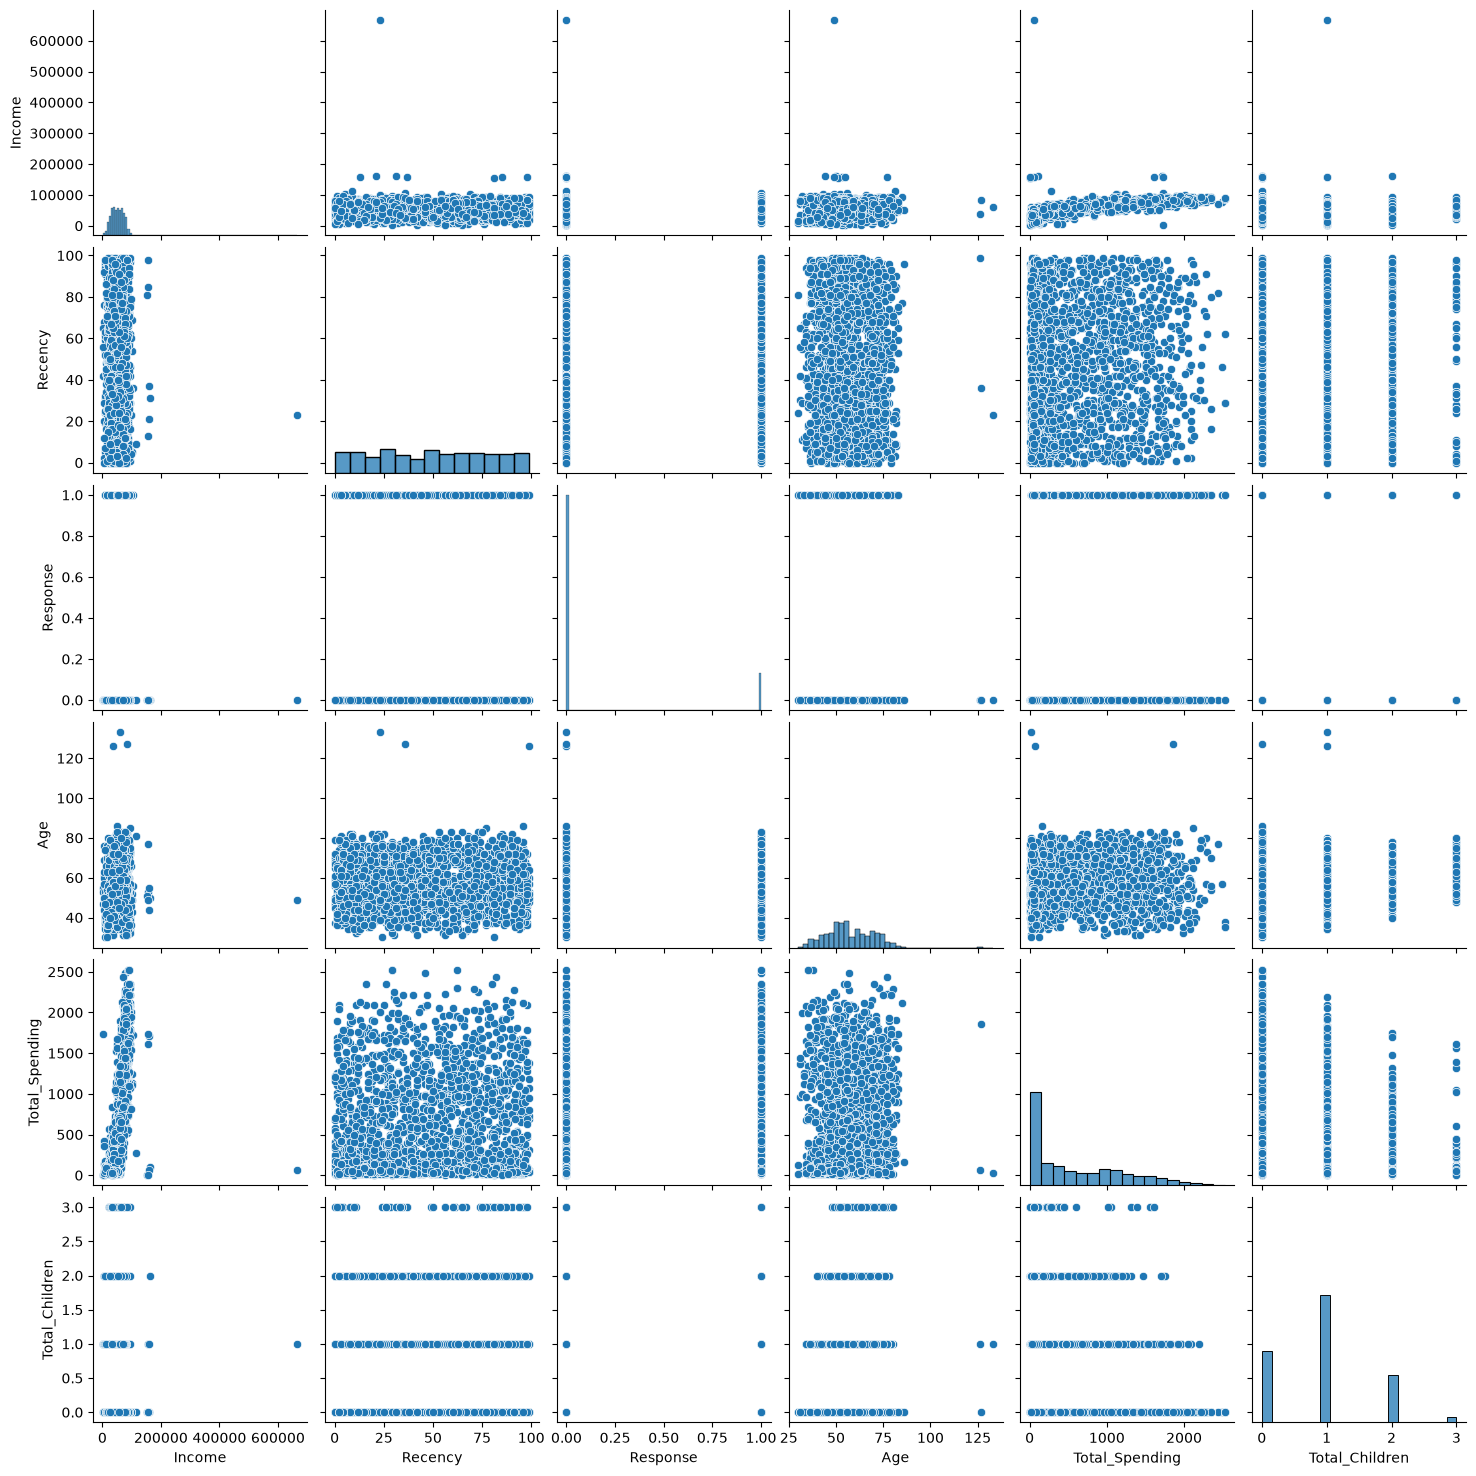

In [15]:
cols=['Income','Recency','Response','Age','Total_Spending','Total_Children']

#relative plots of some features - pair plot

sns.pairplot(df[cols])

In [16]:
# Remove Outliers
print('Whole data size with outliers',len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned['Age']<90)]
df_cleaned=df_cleaned[(df_cleaned['Income']<600_000)]
print('Data size without outliers',len(df_cleaned))

Whole data size with outliers 2240
Data size without outliers 2236


# HeatMap

In [17]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

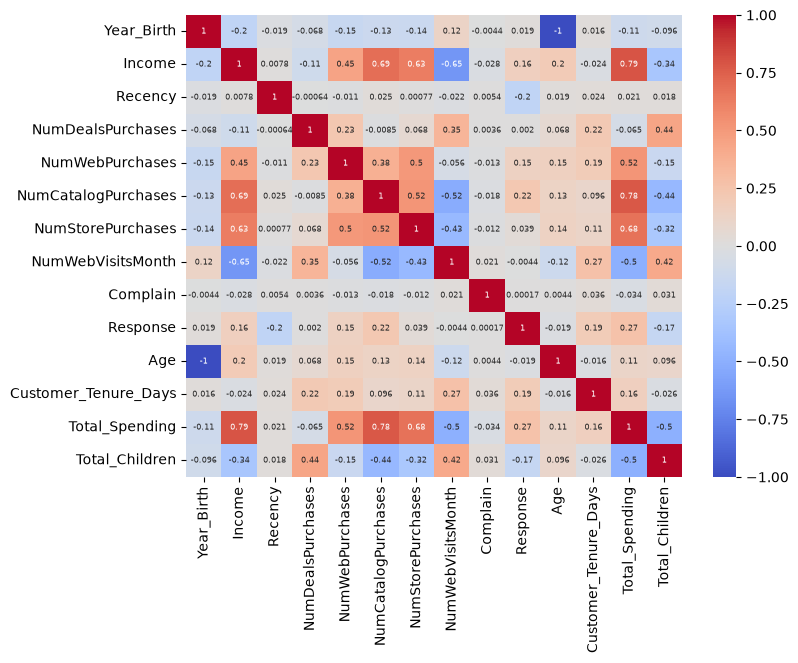

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={'size':6},
    cmap='coolwarm'
)

# Encoding

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [20]:
ohe=OneHotEncoder(sparse_output=False)
cat_cols=['Education','Living_With']
enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [21]:
enc_df=pd.DataFrame(enc_cols,columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [22]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

# Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
X=df_encoded

In [25]:
X.head()

,Year_Birth,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1957,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,1954,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,1965,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,1984,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,1981,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [26]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

# Visualize

In [27]:
from sklearn.decomposition import PCA

In [28]:
pca =PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

In [29]:
pca.explained_variance_ratio_

array([0.22240865, 0.11719198, 0.10725082])

Text(0.5, 0.92, '3d Projection')

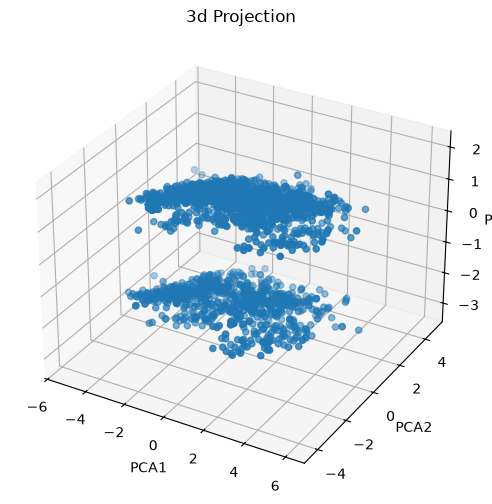

In [30]:
#Plot
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')

ax.set_title('3d Projection')

# Analyze K value
## 1. Elbow Method

In [31]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [32]:
knee=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
optimal_k=knee.elbow

In [33]:
print('Best K=',optimal_k)

Best K= 5


Text(0, 0.5, 'wcss values')

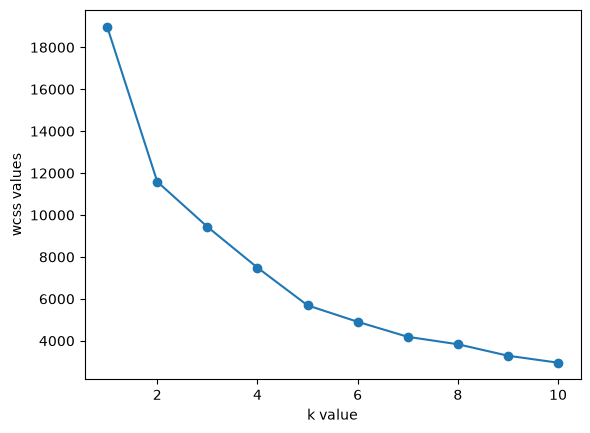

In [34]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('k value')
plt.ylabel('wcss values')

## 2.Silhouette Score

In [35]:
from sklearn.metrics import silhouette_score

In [36]:
scores=[]

for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)

Text(0, 0.5, 'scores')

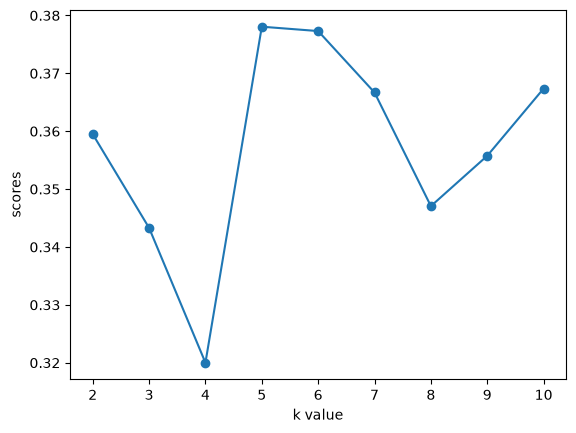

In [37]:
#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel('k value')
plt.ylabel('scores')

# Cluster

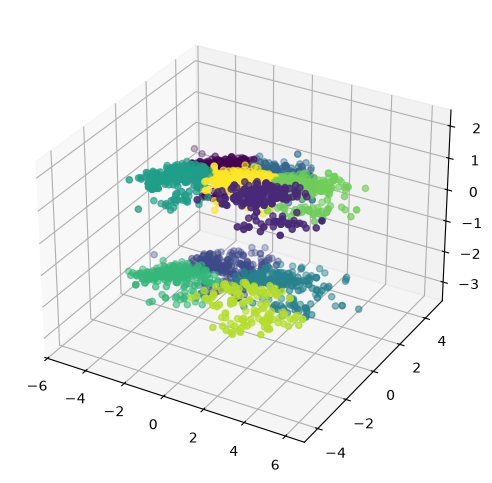

In [38]:
#Kemans
kmeans=KMeans(n_clusters=5,random_state=42)
kmeans_labels=kmeans.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

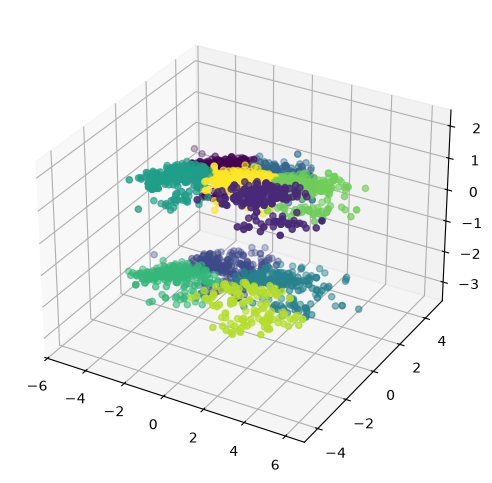

In [39]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agg_clf=AgglomerativeClustering(n_clusters=5,linkage='ward')

agg_labels=agg_clf.fit_predict(X_pca)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels)

In [40]:
kmeans_score=silhouette_score(X_pca,kmeans_labels)
agg_score=silhouette_score(X_pca,agg_labels)

print(kmeans_score,agg_score)

0.3780586529190357 0.34831886134117923


# Characterization Of Clusters

In [62]:
X['cluster']=kmeans_labels

In [63]:
X.head()

,Year_Birth,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,1957,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,2
1,1954,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,4
2,1965,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,1984,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,3
4,1981,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

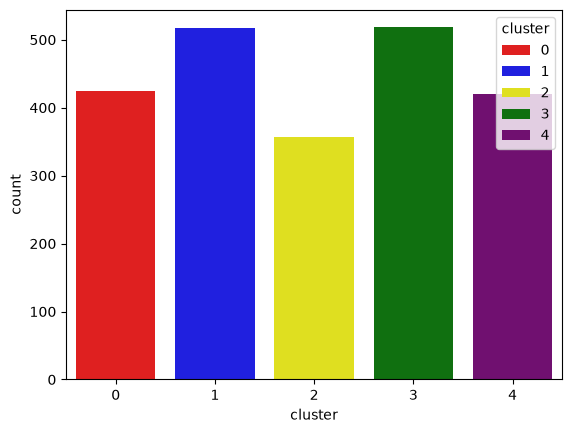

In [64]:
pal=['red','blue','yellow','green','purple']
sns.countplot(x=X['cluster'],palette=pal,hue=X['cluster'])

<Axes: xlabel='Total_Spending', ylabel='Income'>

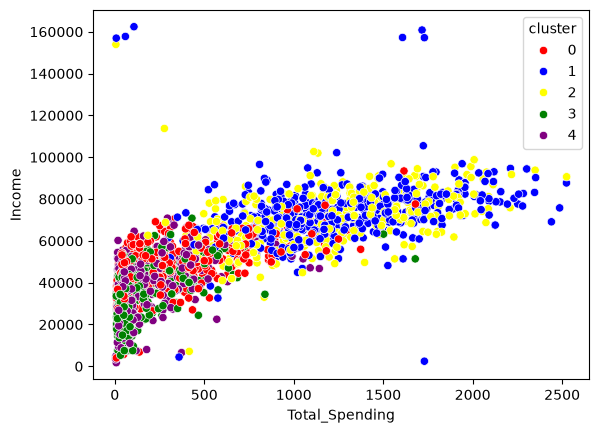

In [65]:
sns.scatterplot(x=X['Total_Spending'],y=X['Income'],hue=X['cluster'],palette=pal)

In [66]:
cluster_summary=X.groupby('cluster').mean()

In [68]:
print(cluster_summary)

          Year_Birth        Income    Recency  NumDealsPurchases  \
cluster                                                            
0        1959.938679  49168.523585  51.443396           3.457547   
1        1967.860735  73086.852031  47.887814           1.820116   
2        1966.714286  70383.836134  50.826331           1.887955   
3        1976.667954  32962.694015  48.498069           2.069498   
4        1971.492857  36502.341667  47.588095           2.495238   

         NumWebPurchases  NumCatalogPurchases  NumStorePurchases  \
cluster                                                            
0               4.259434             1.625000           5.353774   
1               5.700193             5.510638           8.624758   
2               5.795518             5.000000           8.392157   
3               2.364865             0.573359           3.337838   
4               2.602381             0.797619           3.583333   

         NumWebVisitsMonth  Complain  Response